# Análise de Dados - Titanic

Este projeto tem como objetivo analisar o dataset do Titanic, realizando tratamento dos dados e explorando informações relevantes por meio de análises.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('dados/titanic_dataset.csv') 

'''df significa DataFrame, que é uma estrutura de dados bidimensional, semelhante a uma tabela, onde os dados são organizados 
em linhas e colunas.'''

'df significa DataFrame, que é uma estrutura de dados bidimensional, semelhante a uma tabela, onde os dados são organizados \nem linhas e colunas.'

# Visualização inicial dos dados
Aqui eu visualizei as primeiras linhas do dataset para entender como os dados estão organizados e quais colunas existem.

In [4]:
df.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Estrutura dos dados
Aqui eu verifiquei as informações gerais do dataset, como quantidade de linhas, tipos das colunas e presença de valores nulos.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Verificando os valores 
Aqui eu verifiquei a estrutura dos dados e identifiquei a presença de valores faltantes em algumas colunas.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Tratamento dos dados
A coluna Cabin foi removida porque possui muitos valores nulos, o que pode prejudicar a análise.

In [7]:
df = df.drop(columns=['Cabin'])

# Preenchendo valores faltantes
A coluna Age tinha valores faltando, então preenchi esses valores com a média das idades.

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Tratamento dos dados
A coluna Embarked tinha poucos valores nulos, então optei por remover essas linhas.

In [9]:
df = df.dropna(subset=['Embarked'])

# Conferência dos dados
Após o tratamento, visualizei novamente os dados para garantir que as alterações foram aplicadas corretamente.

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# Verificando valores diferentes
Aqui eu verifiquei quantos valores diferentes existem em cada coluna do dataset.

In [11]:
df.nunique()

PassengerId    889
Survived         2
Pclass           3
Name           889
Sex              2
Age             89
SibSp            7
Parch            7
Ticket         680
Fare           247
Embarked         3
dtype: int64

In [12]:
#Pergunta 1: Qual a média do valor da passagem na primeira classe?

round(df[df['Pclass'] == 1]['Fare'].mean(), 2)

np.float64(84.19)

# Explicação Pergunta 1
Aqui eu calculei a média do valor das passagens apenas da primeira classe para entender quanto, em média, essas pessoas pagavam. O resultado foi aproximadamente 84.

In [13]:
# Pergunta 2: Quantas pessoas morreram por classe?

df[df['Survived'] == 0].groupby('Pclass')['PassengerId'].count()

Pclass
1     80
2     97
3    372
Name: PassengerId, dtype: int64

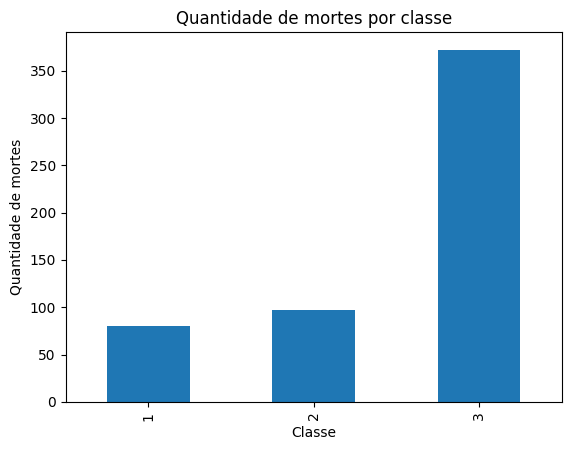

In [14]:
import matplotlib.pyplot as plt

mortes_por_classe = df[df['Survived'] == 0].groupby('Pclass')['PassengerId'].count()

mortes_por_classe.plot(kind='bar')

plt.title('Quantidade de mortes por classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade de mortes')

plt.show()

# Explicação Pergunta 2

Aqui eu filtrei apenas os passageiros que não sobreviveram e depois agrupei por classe para ver quantas mortes ocorreram em cada uma. 
Foi possível observar que a terceira classe teve o maior número de mortes, seguida pela segunda e pela primeira classe.

In [15]:
# Pergunta 3: Quantas mulheres estavam embarcadas e quantas sobreviveram?

mulheres = df[df['Sex'] == 'female']
total_mulheres = mulheres['PassengerId'].count()
sobreviveram = mulheres[mulheres['Survived'] == 1]['PassengerId'].count()

total_mulheres, sobreviveram

(np.int64(312), np.int64(231))

# Explicação Pergunta 3

Aqui eu filtrei apenas as mulheres do dataset, depois contei quantas estavam a bordo e quantas delas sobreviveram, para comparar esses valores. 
Foi possível observar que, das 312 mulheres, 231 sobreviveram.

In [16]:
# Pergunta 4: Qual a média de idade dos sobreviventes?

round(df[df['Survived'] == 1]['Age'].mean(), 2)

np.float64(28.42)

# Explicação Pergunta 4

Aqui eu filtrei apenas os passageiros que sobreviveram e calculei a média das idades para entender, em média, quantos anos tinham essas pessoas. 
O resultado foi aproximadamente 28 anos.

In [17]:
# Pergunta 5: Qual a mediana da idade dos passageiros?

round(df['Age'].median(), 2)

np.float64(29.7)

# Explicação Pergunta 5
Aqui eu calculei a mediana da idade dos passageiros para entender qual é o valor central das idades no dataset. A mediana é menos influenciada por outliers (valores muito altos ou muito baixos) em comparação com a média.

In [18]:
# Pergunta 6: Qual a porcentagem de sobreviventes no dataset?

total = df['PassengerId'].count()
sobreviventes = df[df['Survived'] == 1]['PassengerId'].count()

porcentagem = (sobreviventes / total) * 100
round(porcentagem, 2)

np.float64(38.25)

# Explicação Pergunta 6
Aqui eu calculei a porcentagem de sobreviventes dividindo a quantidade de pessoas que sobreviveram pelo total de passageiros e multiplicando por 100 para obter o valor em porcentagem. 
O resultado foi aproximadamente 38%, mostrando que menos da metade dos passageiros sobreviveu.

In [19]:
# Pergunta 7: Pessoas com família sobreviveram mais?

# Criando coluna para identificar quem tem família
df['Tem_familia'] = (df['SibSp'] > 0) | (df['Parch'] > 0)

# Calculando taxa de sobrevivência
df.groupby('Tem_familia')['Survived'].mean()

Tem_familia
False    0.300935
True     0.505650
Name: Survived, dtype: float64

# Explicação Pergunta 7

Aqui eu identifiquei quais passageiros estavam com família a bordo e depois comparei a taxa de sobrevivência entre quem estava acompanhado e quem estava sozinho.

Sem família (False) → 30% sobreviveram
Com família (True) → 50% sobreviveram

Quem estava com família teve maior chance de sobreviver.

In [ ]:
# Pergunta 8: Qual a taxa de sobrevivência entre homens, mulheres e crianças?

def classificar(pessoa):
    if pessoa['Age'] < 12:
        return 'Criança'
    elif pessoa['Sex'] == 'male':
        return 'Homem'
    else:
        return 'Mulher'

df['Grupo'] = df.apply(classificar, axis=1) 

df.groupby('Grupo')['Survived'].mean()

Grupo
Criança    0.573529
Homem      0.164510
Mulher     0.757143
Name: Survived, dtype: float64

# Explicação Pergunta 8

Aqui eu criei uma nova classificação separando os passageiros em crianças, homens e mulheres, e depois calculei a taxa de sobrevivência para cada grupo.

Crianças: 57% sobreviveram
Homens: 16% sobreviveram
Mulheres: 75% sobreviveram

Mulheres tiveram a maior taxa
Homens a menor
Crianças ficaram no meio